# **PRCL-0019 | Sales Effectiveness — Full Data Science Project**  
**Client: FicZon Inc  |  Category: Product Sales  |  Ref: PM-PR-0019**


# **Project Goals**
    1. Data Exploration Insights — understand sales effectiveness drivers
    2. ML Model — predict Lead Category (High Potential vs Low Potential)  

#1.IMPORT LIBRARIES

In [ ]:
# Install required libraries (run once)
# !pip install mysql-connector-python pandas numpy matplotlib seaborn scikit-learn imbalanced-learn xgboost


In [ ]:
import sys
!{sys.executable} -m pip install mysql-connector-python

import mysql.connector
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, RandomizedSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (classification_report, confusion_matrix, accuracy_score, roc_auc_score, roc_curve, ConfusionMatrixDisplay)
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier
from scipy.stats import uniform, randint

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("Set2")
print("All libraries imported successfully!")

All libraries imported successfully!


# **2. Connect to MySQL Database & Load Data**

In [ ]:
import os
# == Database credentials ==
DB_CONFIG = {
     "host":     "18.136.157.135",
    "port":     3306,
    "database": "project_sales",
    "user":     "dm_team2",
    "password": "DM!$Team&27@9!20!"

}

try:
    conn = mysql.connector.connect(**DB_CONFIG)
    df = pd.read_sql("SELECT *FROM data",conn)
    conn.close()
    print (f"connected! Loaded {df.shape[0]:,} rows * {df.shape[1]} columns")
except Exception as e:
    print(f"connection failed: {e}")
    print("Attempting to load from CSV instead:")
    csv_file = "project_sales_data.csv"
    if os.path.exists(csv_file):
        df = pd.read_csv(csv_file)
        print(f"Loaded from {csv_file}! Contains {df.shape[0]:,} rows * {df.shape[1]} columns")
    else:
        print(f"Error: {csv_file} not found. Please ensure the CSV file is uploaded to the Colab environment or the path is correct.")
        # Raise the error again to prevent `df` from being undefined if both methods fail
        raise FileNotFoundError(f"Missing required data file: {csv_file}")

connected! Loaded 7,422 rows * 9 columns


# 3. Initial Data Exploration

In [ ]:
# == first five rows ==
df.head()

,Created,Product_ID,Source,Mobile,EMAIL,Sales_Agent,Location,Delivery_Mode,Status
0,14-11-2018 10:05,,Website,984XXXXXXX,aXXXXXXX@gmail.com,Sales-Agent-11,,Mode-5,Open
1,14-11-2018 09:22,,Website,XXXXXXX,#VALUE!,Sales-Agent-10,,Mode-5,Open
2,14-11-2018 09:21,,Website,XXXXXXX,dXXXXXXX@yahoo.com,Sales-Agent-10,,Mode-5,Open
3,14-11-2018 08:46,,Website,XXXXXXX,wXXXXXXX@gmail.com,Sales-Agent-10,,Mode-5,Open
4,14-11-2018 07:34,,Website,XXXXXXX,cXXXXXXX@gmail.com,Sales-Agent-10,,Mode-5,Open


In [ ]:
# == last five rows ==
df.tail()

,Created,Product_ID,Source,Mobile,EMAIL,Sales_Agent,Location,Delivery_Mode,Status
7417,28-04-2018 09:45,9,Call,,aXXXXXXX@gmail.com,Sales-Agent-6,Mumbai,Mode-4,LOST
7418,28-04-2018 09:43,15,Call,,#VALUE!,Sales-Agent-12,Other Locations,Mode-5,LOST
7419,28-04-2018 09:20,5,Live Chat-Direct,,sXXXXXXX@gmail.com,Sales-Agent-11,Bangalore,Mode-1,Not Responding
7420,28-04-2018 08:04,21,CRM form,,YXXXXXXX@gmail.com,Sales-Agent-4,Other Locations,Mode-1,Just Enquiry
7421,28-04-2018 07:54,25,Website,,cXXXXXXX@gmail.com,Sales-Agent-3,Chennai,Mode-1,CONVERTED


In [ ]:
# == shape of data ==
df.shape

(7422, 9)

In [ ]:
# == information of the data ==
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7422 entries, 0 to 7421
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Created        7422 non-null   object
 1   Product_ID     7422 non-null   object
 2   Source         7422 non-null   object
 3   Mobile         7422 non-null   object
 4   EMAIL          7422 non-null   object
 5   Sales_Agent    7422 non-null   object
 6   Location       7422 non-null   object
 7   Delivery_Mode  7422 non-null   object
 8   Status         7422 non-null   object
dtypes: object(9)
memory usage: 522.0+ KB


In [ ]:
df.describe(include='all')

,Created,Product_ID,Source,Mobile,EMAIL,Sales_Agent,Location,Delivery_Mode,Status
count,7422,7422,7422,7422,7422,7422,7422,7422,7422
unique,6752,30,26,487,883,13,18,5,11
top,26-09-2018 11:30,18,Call,,#VALUE!,Sales-Agent-4,Other Locations,Mode-5,Junk Lead
freq,4,1711,2547,1810,1701,1500,2500,2975,1536


The `df.describe(include='all')` output provides a summary of the DataFrame's columns:

*   **count**: The number of non-null entries in each column.
*   **unique**: The number of distinct values in each column.
*   **top**: The most frequently occurring value in each column. For example, for the 'Created' column, the most frequent timestamp is '26-09-2018 11:30'. For 'Product_ID', it's '18'. For 'Delivery_Mode', it's 'Mode-5', and for 'Status', it's 'Junk Lead'.
*   **freq**: The frequency (count) of the 'top' value in each column. For example, '26-09-2018 11:30' appears 4 times, 'Product_ID' 18 appears 1711 times, 'Mode-5' appears 2975 times, and 'Junk Lead' appears 1536 times.

This summary helps in understanding the distribution and common values within your dataset, especially for categorical features.

In [ ]:
df['Location'].value_counts()

,count
Location,
Other Locations,2500
Bangalore,2084
Chennai,909
Hyderabad,528
Delhi,471
Mumbai,402
Pune,142
UAE,79
,58


In [ ]:
df['Status'].value_counts()

,count
Status,
Junk Lead,1536
Not Responding,1129
CONVERTED,834
Just Enquiry,760
Potential,708
Long Term,646
In Progress Positive,643
In Progress Negative,626
LOST,440


In [ ]:
df['Sales_Agent'].value_counts()

,count
Sales_Agent,
Sales-Agent-4,1500
Sales-Agent-11,1420
Sales-Agent-5,1190
Sales-Agent-9,879
Sales-Agent-3,781
Sales-Agent-7,736
Sales-Agent-2,389
Sales-Agent-12,269
Sales-Agent-6,114


In [ ]:
df.isnull().sum()

,0
Created,0
Product_ID,0
Source,0
Mobile,0
EMAIL,0
Sales_Agent,0
Location,0
Delivery_Mode,0
Status,0


In [ ]:
missing_percentage = (df.isnull().sum()/len(df))*100
print(missing_percentage)

Created          0.0
Product_ID       0.0
Source           0.0
Mobile           0.0
EMAIL            0.0
Sales_Agent      0.0
Location         0.0
Delivery_Mode    0.0
Status           0.0
dtype: float64


# 4. **Exploratory Data Analysis (EDA)**

## 4.1 Target variable distribution

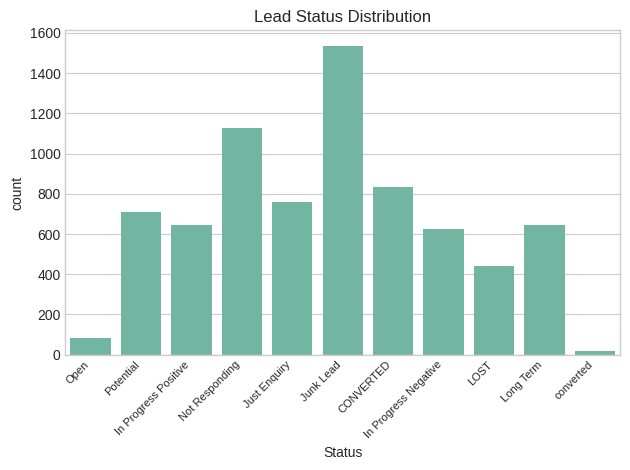

In [ ]:
sns.countplot(x='Status', data=df)
plt.title("Lead Status Distribution")
plt.xticks(rotation=45, ha='right', fontsize=8) # Rotate and resize x-axis labels
plt.tight_layout() # Adjust layout to prevent labels from being cut off
plt.show()

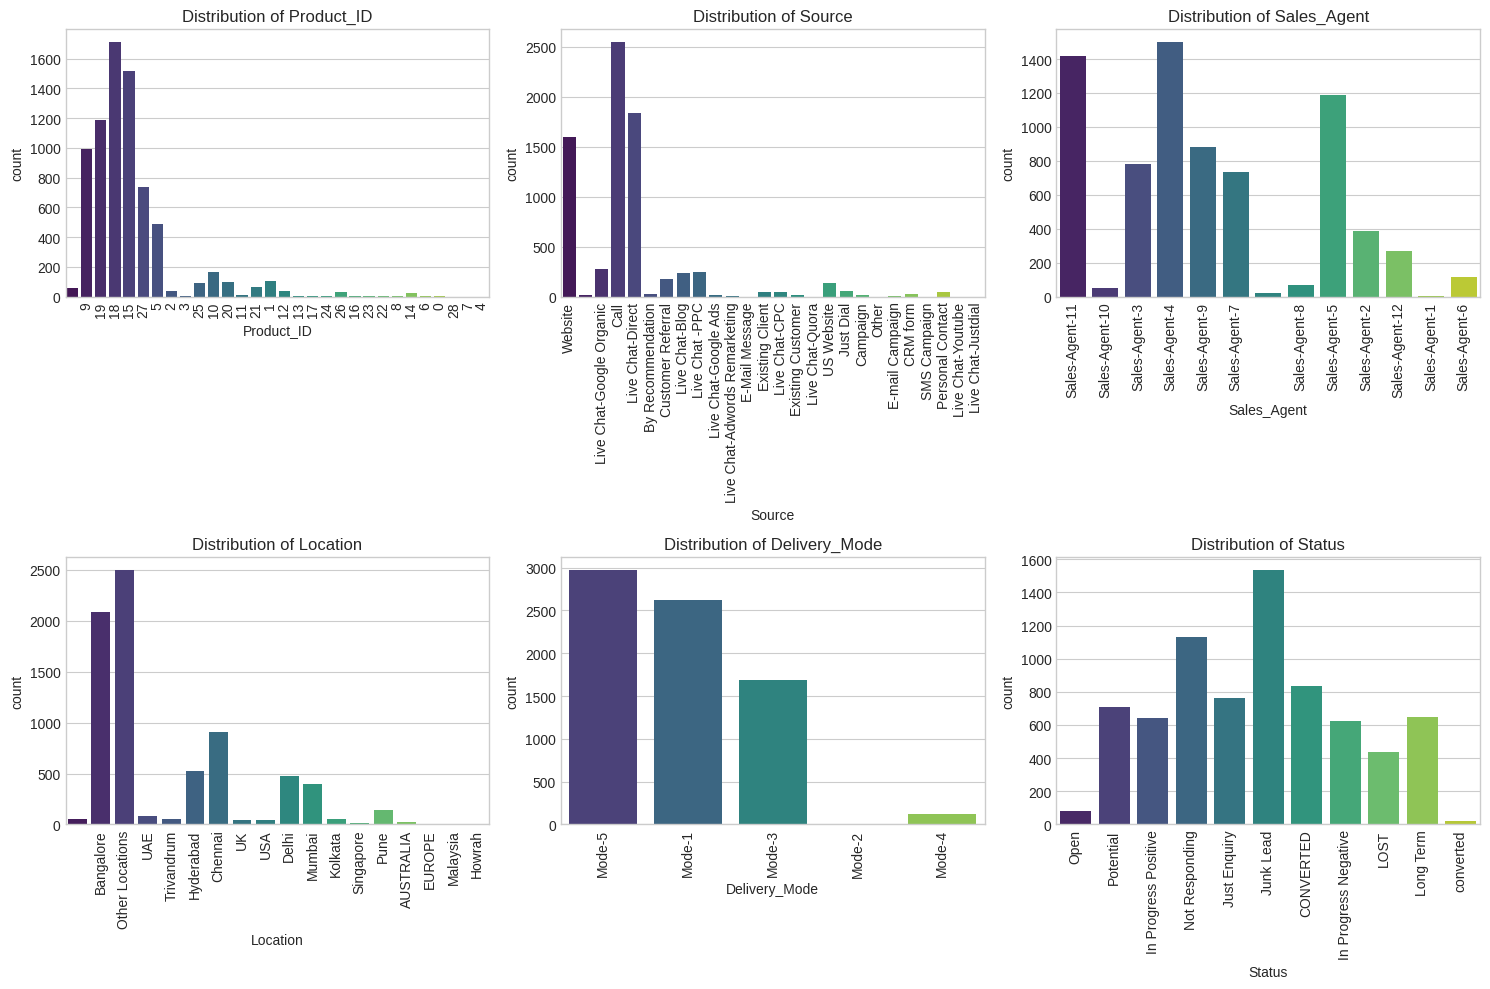

In [ ]:
plt.figure(figsize=(15, 10))
pos = 1

categorical_cols = ['Product_ID', 'Source', 'Sales_Agent', 'Location', 'Delivery_Mode', 'Status']

for col in categorical_cols:
    plt.subplot(2, 3, pos) # Changed to 2 rows, 3 columns
    sns.countplot(x=df[col], palette='viridis') # Changed to countplot
    plt.title(f'Distribution of {col}')
    plt.xticks(rotation=90) # Rotate labels for readability
    pos += 1

plt.tight_layout()
plt.show()

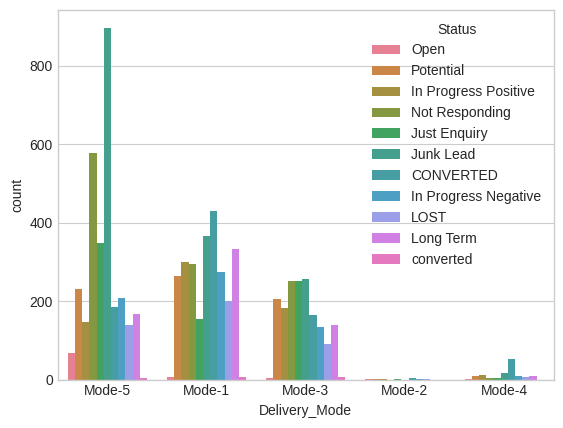

In [ ]:
sns.countplot(x='Delivery_Mode', hue='Status', data=df)
plt.show()

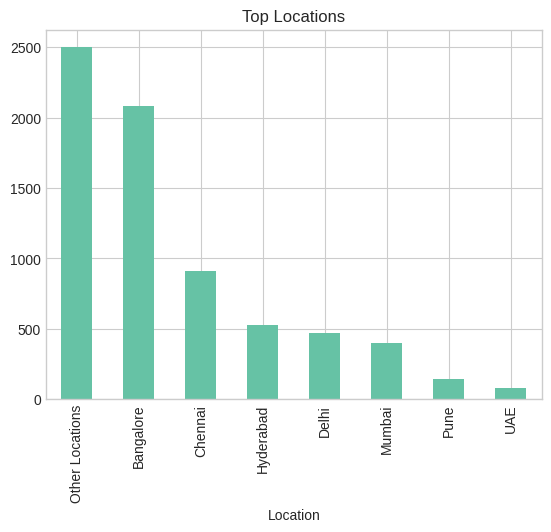

In [ ]:
top_locations = df['Location'].value_counts().head(8)

top_locations.plot(kind='bar')
plt.title("Top Locations")
plt.show()


# 4.2.DATA PREPROCESSING

## Handle '#VALUE!' entries

In [ ]:
df['EMAIL'] = df['EMAIL'].replace('#VALUE!', np.nan)
display(df.head())
print(df['EMAIL'].isnull().sum())

,Created,Product_ID,Source,Mobile,EMAIL,Sales_Agent,Location,Delivery_Mode,Status
0,14-11-2018 10:05,,Website,984XXXXXXX,aXXXXXXX@gmail.com,Sales-Agent-11,,Mode-5,Open
1,14-11-2018 09:22,,Website,XXXXXXX,NaN,Sales-Agent-10,,Mode-5,Open
2,14-11-2018 09:21,,Website,XXXXXXX,dXXXXXXX@yahoo.com,Sales-Agent-10,,Mode-5,Open
3,14-11-2018 08:46,,Website,XXXXXXX,wXXXXXXX@gmail.com,Sales-Agent-10,,Mode-5,Open
4,14-11-2018 07:34,,Website,XXXXXXX,cXXXXXXX@gmail.com,Sales-Agent-10,,Mode-5,Open


1701


# **5.ENCODING**

## 5.1 Target Variable Encoding

Based on the project goal of predicting 'Lead Category (High Potential vs Low Potential)', we will map the 'Status' column to a binary target variable.

*   **High Potential Leads**: 'CONVERTED', 'Potential', 'In Progress Positive'
*   **Low Potential Leads**: 'Junk Lead', 'Not Responding', 'Just Enquiry', 'Long Term', 'In Progress Negative', 'LOST', 'Open'

First, we'll standardize the 'Status' column by converting all entries to uppercase.

In [ ]:
# Standardize 'Status' column to uppercase
df['Status'] = df['Status'].str.upper()

# Define a mapping for High and Low Potential
high_potential_statuses = ['CONVERTED', 'POTENTIAL', 'IN PROGRESS POSITIVE']

def map_to_lead_category(status):
    if status in high_potential_statuses:
        return 1 # High Potential
    else:
        return 0 # Low Potential

df['Lead_Category'] = df['Status'].apply(map_to_lead_category)

# Display the value counts of the new target variable
print("Lead Category Distribution:")
print(df['Lead_Category'].value_counts())
print("\nUpdated DataFrame head with Lead_Category:")
display(df.head())

Lead Category Distribution:
Lead_Category
0    5219
1    2203
Name: count, dtype: int64

Updated DataFrame head with Lead_Category:


,Created,Product_ID,Source,Mobile,EMAIL,Sales_Agent,Location,Delivery_Mode,Status,Lead_Category
0,14-11-2018 10:05,,Website,984XXXXXXX,aXXXXXXX@gmail.com,Sales-Agent-11,,Mode-5,OPEN,0
1,14-11-2018 09:22,,Website,XXXXXXX,NaN,Sales-Agent-10,,Mode-5,OPEN,0
2,14-11-2018 09:21,,Website,XXXXXXX,dXXXXXXX@yahoo.com,Sales-Agent-10,,Mode-5,OPEN,0
3,14-11-2018 08:46,,Website,XXXXXXX,wXXXXXXX@gmail.com,Sales-Agent-10,,Mode-5,OPEN,0
4,14-11-2018 07:34,,Website,XXXXXXX,cXXXXXXX@gmail.com,Sales-Agent-10,,Mode-5,OPEN,0


## 5.2 Feature Engineering from 'Created' Column

We will convert the 'Created' column to datetime objects and extract relevant temporal features such as year, month, day, day of week, and hour. The original 'Created' column will then be dropped.

In [ ]:
# Convert 'Created' to datetime
df['Created'] = pd.to_datetime(df['Created'], format='%d-%m-%Y %H:%M')

# Extract temporal features
df['Created_Year'] = df['Created'].dt.year
df['Created_Month'] = df['Created'].dt.month
df['Created_Day'] = df['Created'].dt.day
df['Created_DayOfWeek'] = df['Created'].dt.dayofweek
df['Created_Hour'] = df['Created'].dt.hour

# Drop the original 'Created' column
df = df.drop(columns=['Created'])

print("DataFrame head after date feature engineering:")
display(df.head())

DataFrame head after date feature engineering:


,Product_ID,Source,Mobile,EMAIL,Sales_Agent,Location,Delivery_Mode,Status,Lead_Category,Created_Year,Created_Month,Created_Day,Created_DayOfWeek,Created_Hour
0,,Website,984XXXXXXX,aXXXXXXX@gmail.com,Sales-Agent-11,,Mode-5,OPEN,0,2018,11,14,2,10
1,,Website,XXXXXXX,NaN,Sales-Agent-10,,Mode-5,OPEN,0,2018,11,14,2,9
2,,Website,XXXXXXX,dXXXXXXX@yahoo.com,Sales-Agent-10,,Mode-5,OPEN,0,2018,11,14,2,9
3,,Website,XXXXXXX,wXXXXXXX@gmail.com,Sales-Agent-10,,Mode-5,OPEN,0,2018,11,14,2,8
4,,Website,XXXXXXX,cXXXXXXX@gmail.com,Sales-Agent-10,,Mode-5,OPEN,0,2018,11,14,2,7


## 5.3 Drop Irrelevant Columns

Columns like 'Mobile' and 'EMAIL' are either anonymized or require complex text processing. For this analysis, we will drop them to simplify the model. The original 'Status' column is also dropped now that we have 'Lead_Category'.

In [ ]:
df = df.drop(columns=['Mobile', 'EMAIL', 'Status'])

print("DataFrame head after dropping irrelevant columns:")
display(df.head())
print("\nUpdated DataFrame info:")
df.info()

DataFrame head after dropping irrelevant columns:


,Product_ID,Source,Sales_Agent,Location,Delivery_Mode,Lead_Category,Created_Year,Created_Month,Created_Day,Created_DayOfWeek,Created_Hour
0,,Website,Sales-Agent-11,,Mode-5,0,2018,11,14,2,10
1,,Website,Sales-Agent-10,,Mode-5,0,2018,11,14,2,9
2,,Website,Sales-Agent-10,,Mode-5,0,2018,11,14,2,9
3,,Website,Sales-Agent-10,,Mode-5,0,2018,11,14,2,8
4,,Website,Sales-Agent-10,,Mode-5,0,2018,11,14,2,7



Updated DataFrame info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7422 entries, 0 to 7421
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Product_ID         7422 non-null   object
 1   Source             7422 non-null   object
 2   Sales_Agent        7422 non-null   object
 3   Location           7422 non-null   object
 4   Delivery_Mode      7422 non-null   object
 5   Lead_Category      7422 non-null   int64 
 6   Created_Year       7422 non-null   int32 
 7   Created_Month      7422 non-null   int32 
 8   Created_Day        7422 non-null   int32 
 9   Created_DayOfWeek  7422 non-null   int32 
 10  Created_Hour       7422 non-null   int32 
dtypes: int32(5), int64(1), object(5)
memory usage: 493.0+ KB


## 5.4 One-Hot Encoding for Categorical Features

We will apply one-hot encoding to the remaining categorical features: 'Product_ID', 'Source', 'Sales_Agent', 'Location', and 'Delivery_Mode'. This converts these categorical variables into a format suitable for machine learning algorithms.

In [ ]:
categorical_features_to_encode = ['Product_ID', 'Source', 'Sales_Agent', 'Location', 'Delivery_Mode']

df_encoded = pd.get_dummies(df, columns=categorical_features_to_encode, drop_first=True)

print("DataFrame head after one-hot encoding:")
display(df_encoded.head())
print("\nShape of the DataFrame after encoding:", df_encoded.shape)
print("\nColumns after encoding:")
print(df_encoded.columns.tolist())

DataFrame head after one-hot encoding:


,Lead_Category,Created_Year,Created_Month,Created_Day,Created_DayOfWeek,Created_Hour,Product_ID_0,Product_ID_1,Product_ID_10,Product_ID_11,...,Location_Pune,Location_Singapore,Location_Trivandrum,Location_UAE,Location_UK,Location_USA,Delivery_Mode_Mode-2,Delivery_Mode_Mode-3,Delivery_Mode_Mode-4,Delivery_Mode_Mode-5
0,0,2018,11,14,2,10,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
1,0,2018,11,14,2,9,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
2,0,2018,11,14,2,9,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
3,0,2018,11,14,2,8,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
4,0,2018,11,14,2,7,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True



Shape of the DataFrame after encoding: (7422, 93)

Columns after encoding:
['Lead_Category', 'Created_Year', 'Created_Month', 'Created_Day', 'Created_DayOfWeek', 'Created_Hour', 'Product_ID_0', 'Product_ID_1', 'Product_ID_10', 'Product_ID_11', 'Product_ID_12', 'Product_ID_13', 'Product_ID_14', 'Product_ID_15', 'Product_ID_16', 'Product_ID_17', 'Product_ID_18', 'Product_ID_19', 'Product_ID_2', 'Product_ID_20', 'Product_ID_21', 'Product_ID_22', 'Product_ID_23', 'Product_ID_24', 'Product_ID_25', 'Product_ID_26', 'Product_ID_27', 'Product_ID_28', 'Product_ID_3', 'Product_ID_4', 'Product_ID_5', 'Product_ID_6', 'Product_ID_7', 'Product_ID_8', 'Product_ID_9', 'Source_By Recommendation', 'Source_CRM form', 'Source_Call', 'Source_Campaign', 'Source_Customer Referral', 'Source_E-Mail Message', 'Source_E-mail Campaign', 'Source_Existing Client', 'Source_Existing Customer', 'Source_Just Dial', 'Source_Live Chat -PPC', 'Source_Live Chat-Adwords Remarketing', 'Source_Live Chat-Blog', 'Source_Live C

In [ ]:
boolean_cols = df_encoded.select_dtypes(include=['bool']).columns

# Convert boolean columns to integer (True=1, False=0)
for col in boolean_cols:
    df_encoded[col] = df_encoded[col].astype(int)

print("DataFrame after converting boolean columns to integers:")
display(df_encoded.head())
print(f"New shape of data: {df_encoded.shape}")

# Verify that there are no more boolean columns
remaining_boolean_cols = df_encoded.select_dtypes(include=['bool']).columns
print(f"Remaining boolean columns: {remaining_boolean_cols.tolist()}")

DataFrame after converting boolean columns to integers:


,Lead_Category,Created_Year,Created_Month,Created_Day,Created_DayOfWeek,Created_Hour,Product_ID_0,Product_ID_1,Product_ID_10,Product_ID_11,...,Location_Pune,Location_Singapore,Location_Trivandrum,Location_UAE,Location_UK,Location_USA,Delivery_Mode_Mode-2,Delivery_Mode_Mode-3,Delivery_Mode_Mode-4,Delivery_Mode_Mode-5
0,0,2018,11,14,2,10,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
1,0,2018,11,14,2,9,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
2,0,2018,11,14,2,9,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
3,0,2018,11,14,2,8,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
4,0,2018,11,14,2,7,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1


New shape of data: (7422, 93)
Remaining boolean columns: []


In [ ]:
# Define features (X) and target (y)
X = df_encoded.drop('Lead_Category', axis=1)
y = df_encoded['Lead_Category']
print(f"Shape of X: {X.shape}, Shape of y: {y.shape}")

Shape of X: (7422, 92), Shape of y: (7422,)



#6. MODEL CREATION

In [ ]:
y = df_encoded['Lead_Category']

In [ ]:
# == split training and testing data ==
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(X,y, train_size = 0.75, random_state = 42)

## 6.1 Outlier Detection and Removal (on Training Data Before SMOTE/Scaling)

We will detect and remove outliers from the training features (`x_train`) using the Interquartile Range (IQR) method. This step is performed before SMOTE and scaling to prevent outliers from distorting these processes.

In [ ]:
# Outlier detection and removal using IQR method on x_train
print("Detecting and removing outliers in x_train using the IQR method...")

# Initialize a boolean Series to mark outliers, same index as x_train
is_outlier_overall = pd.Series(False, index=x_train.index)

for column in x_train.columns:
    # Only apply outlier detection to numerical columns with variance
    if x_train[column].nunique() > 1 and x_train[column].dtype in ['int64', 'float64', 'int32']:
        Q1 = x_train[column].quantile(0.25)
        Q3 = x_train[column].quantile(0.75)
        IQR = Q3 - Q1

        # Handle cases where IQR is zero (e.g., for binary or constant columns)
        if IQR == 0:
            # If all values are the same or only two distinct values are present with no spread
            # We can consider values that are not the most frequent as outliers if desired,
            # but for a general IQR method, a zero IQR means no outliers based on this definition.
            # For now, we will skip if IQR is 0 to avoid flagging common values as outliers in binary features.
            continue

        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        # Update the overall outlier mask for the current column
        is_outlier_overall = is_outlier_overall | ((x_train[column] < lower_bound) | (x_train[column] > upper_bound))

# Get the number of unique rows identified as outliers
outlier_count = is_outlier_overall.sum()

print(f"Number of outliers detected in x_train: {outlier_count}")

# Remove outliers from x_train and y_train using the boolean mask
x_train_cleaned = x_train[~is_outlier_overall]
y_train_cleaned = y_train[~is_outlier_overall]

print(f"x_train shape after outlier removal: {x_train_cleaned.shape}")
print(f"y_train shape after outlier removal: {y_train_cleaned.shape}")

if outlier_count > 0:
    print("First 10 indices of outliers removed (from x_train's perspective, not original df):")
    # Displaying actual indices from x_train's index that were removed
    removed_indices = x_train.index[is_outlier_overall].tolist()
    print(removed_indices[:10])
else:
    print("No outliers detected based on the IQR method in x_train.")

Detecting and removing outliers in x_train using the IQR method...
Number of outliers detected in x_train: 134
x_train shape after outlier removal: (5432, 92)
y_train shape after outlier removal: (5432,)
First 10 indices of outliers removed (from x_train's perspective, not original df):
[5913, 2441, 2907, 4245, 1340, 3328, 4246, 3739, 6828, 6571]


In [ ]:
print("Detecting outliers in x_train_cleaned using the IQR method...")

outlier_indices = np.array([])

for column in x_train_cleaned.columns:
    Q1 = x_train_cleaned[column].quantile(0.25)
    Q3 = x_train_cleaned[column].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Find indices of outliers for the current column
    # We need to make sure we're using the indices from the current DataFrame
    column_outliers = x_train_cleaned[(x_train_cleaned[column] < lower_bound) | (x_train_cleaned[column] > upper_bound)].index
    outlier_indices = np.append(outlier_indices, column_outliers)

# Get unique outlier indices across all columns and ensure they are integers
outlier_indices = np.unique(outlier_indices).astype(int)

print(f"Number of outliers detected: {len(outlier_indices)}")

if len(outlier_indices) > 0:
    print("First 10 outlier indices:")
    print(outlier_indices[:10])
else:
    print("No outliers detected based on the IQR method in x_train_smote.")

Detecting outliers in x_train_cleaned using the IQR method...
Number of outliers detected: 5432
First 10 outlier indices:
[ 1  2  3  4  5  6  7  9 10 11]


#   6.3. Visualization of Outliers Before and After Removal
To understand the effect of outlier removal, let's visualize the distribution of a sample numerical feature before and after removing the identified outliers using box plots.

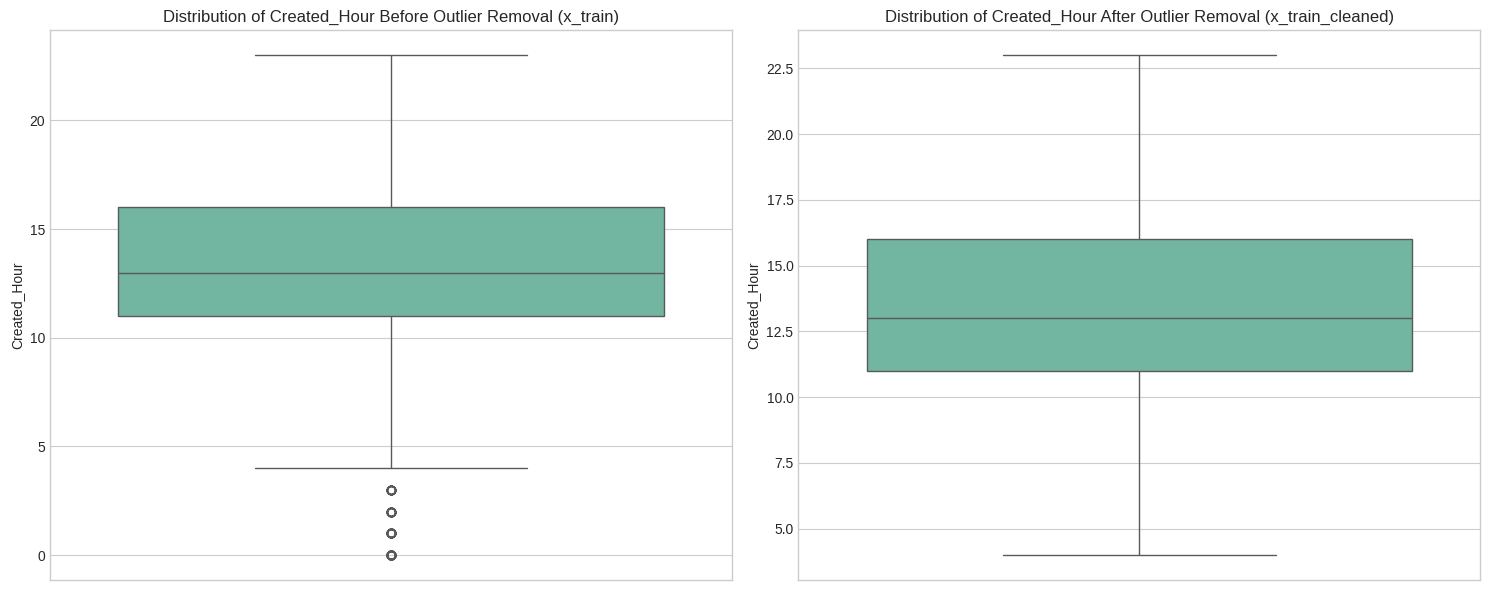

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Choose a numerical feature to visualize (e.g., 'Created_Hour')
# Ensure the chosen feature exists in both x_train and x_train_cleaned
feature_to_plot = 'Created_Hour'

# Create a figure with two subplots
plt.figure(figsize=(15, 6))

# Box plot before outlier removal (using x_train)
plt.subplot(1, 2, 1) # 1 row, 2 columns, first plot
sns.boxplot(y=x_train[feature_to_plot])
plt.title(f'Distribution of {feature_to_plot} Before Outlier Removal (x_train)')
plt.ylabel(feature_to_plot)

# Box plot after outlier removal (using x_train_cleaned)
plt.subplot(1, 2, 2) # 1 row, 2 columns, second plot
sns.boxplot(y=x_train_cleaned[feature_to_plot])
plt.title(f'Distribution of {feature_to_plot} After Outlier Removal (x_train_cleaned)')
plt.ylabel(feature_to_plot)

plt.tight_layout() # Adjust layout to prevent overlapping titles/labels
plt.show()

# 8.SCALING

In [ ]:
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(x_train_smote) # Scale SMOTEd data
X_test_sc  = scaler.transform(x_test)
print(" Features scaled")

 Features scaled


In [ ]:
from sklearn.preprocessing import StandardScaler

# Features and Target
X = df_encoded.drop('Lead_Category', axis=1)
y = df_encoded['Lead_Category']

# Scaling
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

# Convert back to DataFrame (optional)
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

X_scaled.head()

,Created_Year,Created_Month,Created_Day,Created_DayOfWeek,Created_Hour,Product_ID_0,Product_ID_1,Product_ID_10,Product_ID_11,Product_ID_12,...,Location_Pune,Location_Singapore,Location_Trivandrum,Location_UAE,Location_UK,Location_USA,Delivery_Mode_Mode-2,Delivery_Mode_Mode-3,Delivery_Mode_Mode-4,Delivery_Mode_Mode-5
0,0.0,1.864294,-0.182295,-0.202204,-0.821831,-0.016418,-0.119792,-0.152183,-0.040242,-0.069815,...,-0.139662,-0.047914,-0.088748,-0.103723,-0.074531,-0.078103,-0.038526,-0.542572,-0.128736,1.222616
1,0.0,1.864294,-0.182295,-0.202204,-1.068420,-0.016418,-0.119792,-0.152183,-0.040242,-0.069815,...,-0.139662,-0.047914,-0.088748,-0.103723,-0.074531,-0.078103,-0.038526,-0.542572,-0.128736,1.222616
2,0.0,1.864294,-0.182295,-0.202204,-1.068420,-0.016418,-0.119792,-0.152183,-0.040242,-0.069815,...,-0.139662,-0.047914,-0.088748,-0.103723,-0.074531,-0.078103,-0.038526,-0.542572,-0.128736,1.222616
3,0.0,1.864294,-0.182295,-0.202204,-1.315009,-0.016418,-0.119792,-0.152183,-0.040242,-0.069815,...,-0.139662,-0.047914,-0.088748,-0.103723,-0.074531,-0.078103,-0.038526,-0.542572,-0.128736,1.222616
4,0.0,1.864294,-0.182295,-0.202204,-1.561598,-0.016418,-0.119792,-0.152183,-0.040242,-0.069815,...,-0.139662,-0.047914,-0.088748,-0.103723,-0.074531,-0.078103,-0.038526,-0.542572,-0.128736,1.222616


In [ ]:
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler
import pandas as pd

# Ensure X and X_scaled are defined
X = df_encoded.drop('Lead_Category', axis=1)
y = df_encoded['Lead_Category']

# Scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Convert back to DataFrame (optional, but good for consistency with original code)
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

# Initialize Isolation Forest model
# contamination is the proportion of outliers in the data set. A value between 0 and 0.5.
# We can start with an estimate, e.g., 0.05 (5% outliers), or tune this parameter.
isolation_forest = IsolationForest(random_state=42, contamination=0.05)

# Fit the model and predict outliers (returns -1 for outliers, 1 for inliers)
# We'll apply it to the scaled features (X_scaled)
outliers = isolation_forest.fit_predict(X_scaled)

# Add the outlier predictions to our scaled DataFrame for analysis
X_scaled_with_outliers = X_scaled.copy()
X_scaled_with_outliers['outlier'] = outliers

# Count the number of outliers and inliers
print(f"Number of outliers: {X_scaled_with_outliers[X_scaled_with_outliers['outlier'] == -1].shape[0]}")
print(f"Number of inliers: {X_scaled_with_outliers[X_scaled_with_outliers['outlier'] == 1].shape[0]}")

# Display the head of the DataFrame with outlier labels
print("\nDataFrame head with outlier labels:")
display(X_scaled_with_outliers.head())

Number of outliers: 372
Number of inliers: 7050

DataFrame head with outlier labels:


,Created_Year,Created_Month,Created_Day,Created_DayOfWeek,Created_Hour,Product_ID_0,Product_ID_1,Product_ID_10,Product_ID_11,Product_ID_12,...,Location_Singapore,Location_Trivandrum,Location_UAE,Location_UK,Location_USA,Delivery_Mode_Mode-2,Delivery_Mode_Mode-3,Delivery_Mode_Mode-4,Delivery_Mode_Mode-5,outlier
0,0.0,1.864294,-0.182295,-0.202204,-0.821831,-0.016418,-0.119792,-0.152183,-0.040242,-0.069815,...,-0.047914,-0.088748,-0.103723,-0.074531,-0.078103,-0.038526,-0.542572,-0.128736,1.222616,1
1,0.0,1.864294,-0.182295,-0.202204,-1.068420,-0.016418,-0.119792,-0.152183,-0.040242,-0.069815,...,-0.047914,-0.088748,-0.103723,-0.074531,-0.078103,-0.038526,-0.542572,-0.128736,1.222616,1
2,0.0,1.864294,-0.182295,-0.202204,-1.068420,-0.016418,-0.119792,-0.152183,-0.040242,-0.069815,...,-0.047914,-0.088748,-0.103723,-0.074531,-0.078103,-0.038526,-0.542572,-0.128736,1.222616,1
3,0.0,1.864294,-0.182295,-0.202204,-1.315009,-0.016418,-0.119792,-0.152183,-0.040242,-0.069815,...,-0.047914,-0.088748,-0.103723,-0.074531,-0.078103,-0.038526,-0.542572,-0.128736,1.222616,1
4,0.0,1.864294,-0.182295,-0.202204,-1.561598,-0.016418,-0.119792,-0.152183,-0.040242,-0.069815,...,-0.047914,-0.088748,-0.103723,-0.074531,-0.078103,-0.038526,-0.542572,-0.128736,1.222616,1


In [ ]:
from sklearn.preprocessing import RobustScaler

# Initialize RobustScaler
robust_scaler = RobustScaler()

# Apply robust scaling to the features
X_robust_scaled = robust_scaler.fit_transform(X)

# Convert back to DataFrame (optional) for better readability
X_robust_scaled = pd.DataFrame(X_robust_scaled, columns=X.columns)

print("DataFrame head after robust scaling:")
display(X_robust_scaled.head())

DataFrame head after robust scaling:


,Created_Year,Created_Month,Created_Day,Created_DayOfWeek,Created_Hour,Product_ID_0,Product_ID_1,Product_ID_10,Product_ID_11,Product_ID_12,...,Location_Pune,Location_Singapore,Location_Trivandrum,Location_UAE,Location_UK,Location_USA,Delivery_Mode_Mode-2,Delivery_Mode_Mode-3,Delivery_Mode_Mode-4,Delivery_Mode_Mode-5
0,0.0,1.333333,-0.066667,0.0,-0.6,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1,0.0,1.333333,-0.066667,0.0,-0.8,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
2,0.0,1.333333,-0.066667,0.0,-0.8,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
3,0.0,1.333333,-0.066667,0.0,-1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
4,0.0,1.333333,-0.066667,0.0,-1.2,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


RobustScaler scales features using statistics that are robust to outliers. It removes the median and scales the data according to the quantile range (the IQR - Interquartile Range). The IQR is the range between the 1st quartile (25th quantile) and the 3rd quartile (75th quantile).

This method is particularly useful when dealing with datasets that contain outliers, as standard scaling methods (like `StandardScaler`) can be heavily influenced by these extreme values.

##8.1. Handling Imbalanced Data with SMOTE

Our target variable `Lead_Category` is imbalanced, with a significantly higher number of 'Low Potential' leads (class 0) than 'High Potential' leads (class 1). This can lead to models that perform poorly on the minority class.

To address this, we will use **SMOTE (Synthetic Minority Over-sampling Technique)**. SMOTE works by creating synthetic samples of the minority class, rather than simply duplicating existing ones. It does this by taking a sample from the minority class and introducing synthetic examples along the line segments joining any of the k minority class nearest neighbors.

In [ ]:
# Apply SMOTE to the training data (should be on cleaned data)
smote = SMOTE(random_state=42)
x_train_smote, y_train_smote = smote.fit_resample(x_train_cleaned, y_train_cleaned)

print("Class distribution after SMOTE:")
print(y_train_smote.value_counts())

Class distribution after SMOTE:
Lead_Category
0    3848
1    3848
Name: count, dtype: int64



# 9.FEATURE SELECTION

# **9.1.CORRELATION**

In [ ]:
df_encoded.corr()

,Lead_Category,Created_Year,Created_Month,Created_Day,Created_DayOfWeek,Created_Hour,Product_ID_0,Product_ID_1,Product_ID_10,Product_ID_11,...,Location_Pune,Location_Singapore,Location_Trivandrum,Location_UAE,Location_UK,Location_USA,Delivery_Mode_Mode-2,Delivery_Mode_Mode-3,Delivery_Mode_Mode-4,Delivery_Mode_Mode-5
Lead_Category,1.000000,NaN,0.146963,0.026151,-0.011103,0.036715,-0.010667,-0.042868,0.061733,0.003216,...,-0.030459,0.012055,0.002627,0.036071,0.027178,0.006242,0.020967,0.040784,0.086364,-0.190189
Created_Year,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Created_Month,0.146963,NaN,1.000000,-0.135487,0.011908,-0.040089,0.000005,-0.017282,-0.013947,0.014299,...,-0.020388,0.005267,0.023658,0.023454,-0.001431,0.018047,0.025192,0.198730,-0.017245,0.033838
Created_Day,0.026151,NaN,-0.135487,1.000000,-0.061613,-0.002339,-0.020246,-0.016285,0.007630,0.015664,...,-0.009140,-0.008734,-0.025657,-0.008161,0.002098,-0.008478,-0.010510,-0.009306,0.014664,0.041708
Created_DayOfWeek,-0.011103,NaN,0.011908,-0.061613,1.000000,-0.048571,-0.016764,-0.026091,-0.014947,-0.008137,...,-0.008910,-0.001995,0.003774,-0.010938,-0.023010,-0.005370,-0.017350,0.029794,0.000687,-0.039609
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Location_USA,0.006242,NaN,0.018047,-0.008478,-0.005370,-0.012401,-0.001282,-0.009356,-0.011886,-0.003143,...,-0.010908,-0.003742,-0.006931,-0.008101,-0.005821,1.000000,-0.003009,0.061138,0.031061,-0.003675
Delivery_Mode_Mode-2,0.020967,NaN,0.025192,-0.010510,-0.017350,-0.003162,-0.000633,-0.004615,0.088327,-0.001550,...,-0.005381,-0.001846,-0.003419,-0.003996,0.091636,-0.003009,1.000000,-0.020903,-0.004960,-0.031511
Delivery_Mode_Mode-3,0.040784,NaN,0.198730,-0.009306,0.029794,0.044881,0.010676,-0.021448,-0.011256,0.010167,...,0.041542,0.041242,0.050408,0.090938,0.033285,0.061138,-0.020903,1.000000,-0.069849,-0.443780
Delivery_Mode_Mode-4,0.086364,NaN,-0.017245,0.014664,0.000687,0.010162,-0.002114,-0.015422,0.080552,-0.005181,...,-0.010213,-0.006168,-0.011425,0.028118,0.004760,0.031061,-0.004960,-0.069849,1.000000,-0.105296


In [ ]:
# Checking multicollinearity
res = X[X.columns].corr()
res

,Created_Year,Created_Month,Created_Day,Created_DayOfWeek,Created_Hour,Product_ID_0,Product_ID_1,Product_ID_10,Product_ID_11,Product_ID_12,...,Location_Pune,Location_Singapore,Location_Trivandrum,Location_UAE,Location_UK,Location_USA,Delivery_Mode_Mode-2,Delivery_Mode_Mode-3,Delivery_Mode_Mode-4,Delivery_Mode_Mode-5
Created_Year,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Created_Month,NaN,1.000000,-0.135487,0.011908,-0.040089,0.000005,-0.017282,-0.013947,0.014299,0.012414,...,-0.020388,0.005267,0.023658,0.023454,-0.001431,0.018047,0.025192,0.198730,-0.017245,0.033838
Created_Day,NaN,-0.135487,1.000000,-0.061613,-0.002339,-0.020246,-0.016285,0.007630,0.015664,-0.009294,...,-0.009140,-0.008734,-0.025657,-0.008161,0.002098,-0.008478,-0.010510,-0.009306,0.014664,0.041708
Created_DayOfWeek,NaN,0.011908,-0.061613,1.000000,-0.048571,-0.016764,-0.026091,-0.014947,-0.008137,0.011292,...,-0.008910,-0.001995,0.003774,-0.010938,-0.023010,-0.005370,-0.017350,0.029794,0.000687,-0.039609
Created_Hour,NaN,-0.040089,-0.002339,-0.048571,1.000000,0.000677,-0.003641,0.021464,0.030602,0.020572,...,0.014975,-0.019222,0.004791,0.019331,0.007331,-0.012401,-0.003162,0.044881,0.010162,-0.111188
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Location_USA,NaN,0.018047,-0.008478,-0.005370,-0.012401,-0.001282,-0.009356,-0.011886,-0.003143,-0.005453,...,-0.010908,-0.003742,-0.006931,-0.008101,-0.005821,1.000000,-0.003009,0.061138,0.031061,-0.003675
Delivery_Mode_Mode-2,NaN,0.025192,-0.010510,-0.017350,-0.003162,-0.000633,-0.004615,0.088327,-0.001550,-0.002690,...,-0.005381,-0.001846,-0.003419,-0.003996,0.091636,-0.003009,1.000000,-0.020903,-0.004960,-0.031511
Delivery_Mode_Mode-3,NaN,0.198730,-0.009306,0.029794,0.044881,0.010676,-0.021448,-0.011256,0.010167,-0.028627,...,0.041542,0.041242,0.050408,0.090938,0.033285,0.061138,-0.020903,1.000000,-0.069849,-0.443780
Delivery_Mode_Mode-4,NaN,-0.017245,0.014664,0.000687,0.010162,-0.002114,-0.015422,0.080552,-0.005181,0.144150,...,-0.010213,-0.006168,-0.011425,0.028118,0.004760,0.031061,-0.004960,-0.069849,1.000000,-0.105296


In [ ]:
res[res>0.85]

,Created_Year,Created_Month,Created_Day,Created_DayOfWeek,Created_Hour,Product_ID_0,Product_ID_1,Product_ID_10,Product_ID_11,Product_ID_12,...,Location_Pune,Location_Singapore,Location_Trivandrum,Location_UAE,Location_UK,Location_USA,Delivery_Mode_Mode-2,Delivery_Mode_Mode-3,Delivery_Mode_Mode-4,Delivery_Mode_Mode-5
Created_Year,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Created_Month,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Created_Day,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Created_DayOfWeek,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Created_Hour,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Location_USA,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN
Delivery_Mode_Mode-2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN
Delivery_Mode_Mode-3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN
Delivery_Mode_Mode-4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN


### **9.2.Dimensionality Reduction with PCA**

Principal Component Analysis (PCA) is a popular technique for dimensionality reduction. It transforms the data into a new coordinate system such that the greatest variance by any projection of the data lies on the first coordinate (called the first principal component), the second greatest variance on the second coordinate, and so on. This helps in reducing the number of features while retaining as much information (variance) as possible.

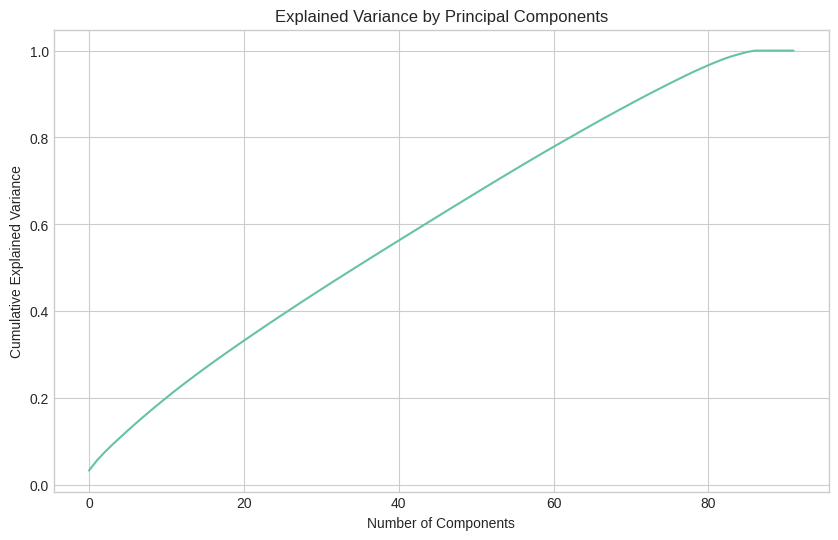

Explained variance ratio of the first 5 components:
[0.03289328 0.02295219 0.01892157 0.01753637 0.01649579]

Number of components to explain 95% of variance: 79

Original number of features: 92
Number of features after PCA (retaining 95% variance): 79

First 5 rows of PCA transformed data:


,0,1,2,3,4,5,6,7,8,9,...,69,70,71,72,73,74,75,76,77,78
0,0.938784,-0.850060,-0.174407,1.127751,1.297120,0.171929,-0.366489,0.138592,2.026532,0.632760,...,-0.355000,-0.035852,0.372610,0.212260,-0.163464,-0.033308,-0.649800,-0.535497,-0.344987,-0.294114
1,0.746691,-0.913893,-1.391323,1.391632,3.759923,-0.198776,-0.233493,1.527591,4.016407,0.943248,...,1.105714,-2.368358,0.482241,-1.375158,-2.779112,-1.519837,0.110718,0.157759,-4.319760,3.702407
2,0.746691,-0.913893,-1.391323,1.391632,3.759923,-0.198776,-0.233493,1.527591,4.016407,0.943248,...,1.105714,-2.368358,0.482241,-1.375158,-2.779112,-1.519837,0.110718,0.157759,-4.319760,3.702407
3,0.784790,-0.899548,-1.414210,1.402977,3.732013,-0.196989,-0.226614,1.562053,4.005704,0.924433,...,1.038513,-2.374832,0.494806,-1.389695,-2.786746,-1.507206,0.061762,0.109094,-4.450378,3.724489
4,0.822890,-0.885203,-1.437097,1.414321,3.704104,-0.195202,-0.219736,1.596514,3.995002,0.905618,...,0.971313,-2.381305,0.507371,-1.404231,-2.794379,-1.494576,0.012806,0.060429,-4.580997,3.746571


In [ ]:
from sklearn.decomposition import PCA

# Initialize PCA. You can specify n_components, or leave it None to get all components
# and then decide how many to keep based on explained variance.
# For now, let's keep all components to analyze the variance.
pca = PCA(n_components=None, random_state=42)

# Fit PCA on the scaled training data (X_scaled)
pca.fit(X_scaled)

# Plot the explained variance ratio
plt.figure(figsize=(10, 6))
plt.plot(np.cumsum(pca.explained_variance_ratio_))
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('Explained Variance by Principal Components')
plt.grid(True)
plt.show()

# Display the explained variance ratio for the first few components
print("Explained variance ratio of the first 5 components:")
print(pca.explained_variance_ratio_[:5])

# You can choose the number of components that explain a significant portion of variance, e.g., 95%
# Let's find out how many components are needed for 95% variance
cumulative_variance = np.cumsum(pca.explained_variance_ratio_)
num_components_95 = np.where(cumulative_variance >= 0.95)[0][0] + 1
print(f"\nNumber of components to explain 95% of variance: {num_components_95}")

# Now, apply PCA with the selected number of components
pca_final = PCA(n_components=num_components_95, random_state=42)
X_pca = pca_final.fit_transform(X_scaled)

print(f"\nOriginal number of features: {X_scaled.shape[1]}")
print(f"Number of features after PCA (retaining 95% variance): {X_pca.shape[1]}")
print("\nFirst 5 rows of PCA transformed data:")
display(pd.DataFrame(X_pca).head())

In [ ]:
y_train.value_counts()

,count
Lead_Category,
0,3951
1,1615



# **10.MODEL EVALUATION**

LOGISTIC REGRESSION

In [ ]:
# X_train_sc and X_test_sc are already scaled in a previous cell (vaDAe3Xs_xWl)
# Remove redundant scaling if it's already done.

model = LogisticRegression(max_iter=10000, random_state=32) # Adjusted max_iter as requested

model.fit(X_train_sc, y_train_smote)

LogisticRegression(max_iter=10000, random_state=32)

In [ ]:
y_pred = model.predict(X_test_sc)

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy :", accuracy)

Accuracy : 0.7483836206896551


In [ ]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.77      0.90      0.83      1268
           1       0.66      0.42      0.51       588

    accuracy                           0.75      1856
   macro avg       0.72      0.66      0.67      1856
weighted avg       0.74      0.75      0.73      1856



### Decision Tree Classifier

In [ ]:
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train_sc, y_train_smote)

y_pred_dt = dt_model.predict(X_test_sc)
accuracy_dt = accuracy_score(y_test, y_pred_dt)
print(f"Decision Tree Accuracy: {accuracy_dt:.4f}")
print(classification_report(y_test, y_pred_dt))

Decision Tree Accuracy: 0.6627
              precision    recall  f1-score   support

           0       0.75      0.75      0.75      1268
           1       0.47      0.47      0.47       588

    accuracy                           0.66      1856
   macro avg       0.61      0.61      0.61      1856
weighted avg       0.66      0.66      0.66      1856



### Random Forest Classifier

In [ ]:
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train_sc, y_train_smote)

y_pred_rf = rf_model.predict(X_test_sc)
accuracy_rf = accuracy_score(y_test, y_pred_rf)
print(f"Random Forest Accuracy: {accuracy_rf:.4f}")
print(classification_report(y_test, y_pred_rf))

Random Forest Accuracy: 0.7338
              precision    recall  f1-score   support

           0       0.77      0.87      0.82      1268
           1       0.61      0.44      0.51       588

    accuracy                           0.73      1856
   macro avg       0.69      0.66      0.67      1856
weighted avg       0.72      0.73      0.72      1856



### Gradient Boosting Classifier

In [ ]:
gb_model = GradientBoostingClassifier(random_state=42)
gb_model.fit(X_train_sc, y_train_smote)

y_pred_gb = gb_model.predict(X_test_sc)
accuracy_gb = accuracy_score(y_test, y_pred_gb)
print(f"Gradient Boosting Accuracy: {accuracy_gb:.4f}")
print(classification_report(y_test, y_pred_gb))

Gradient Boosting Accuracy: 0.7462
              precision    recall  f1-score   support

           0       0.81      0.82      0.82      1268
           1       0.60      0.59      0.60       588

    accuracy                           0.75      1856
   macro avg       0.71      0.70      0.71      1856
weighted avg       0.74      0.75      0.75      1856



### XGBoost Classifier

XGBoost (Extreme Gradient Boosting) is an optimized distributed gradient boosting library designed to be highly efficient, flexible, and portable. It implements machine learning algorithms under the Gradient Boosting framework. XGBoost provides a parallel tree boosting (also known as GBDT, GBM) that solves many data science problems in a fast and accurate way.

We will now train an XGBoost model and perform hyperparameter tuning using `GridSearchCV` to find the best configuration.

In [ ]:
from xgboost import XGBClassifier

# Define the parameter grid for GridSearchCV for XGBoost
xgb_param_grid = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [3, 5, 7],
    'subsample': [0.7, 0.8, 0.9],
    'colsample_bytree': [0.7, 0.8, 0.9] # Subsample ratio of columns when constructing each tree
}

# Initialize GridSearchCV for XGBoost
xgb_grid = GridSearchCV(
    XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42), # Suppress warnings with use_label_encoder=False and eval_metric
    xgb_param_grid, cv=5, scoring='roc_auc', n_jobs=-1, verbose=1
)

# Fit GridSearchCV to the SMOTE-resampled training data
xgb_grid.fit(X_train_sc, y_train_smote)

# Print the best parameters and best CV ROC-AUC score
print(f"\n✅ Best parameters for XGBoost:  {xgb_grid.best_params_}")
print(f"   Best CV ROC-AUC for XGBoost: {xgb_grid.best_score_:.4f}")

# Get the best XGBoost model
best_xgb_model = xgb_grid.best_estimator_

# Make predictions and calculate probabilities on the test set
y_pred_xgb_tuned  = best_xgb_model.predict(X_test_sc)
y_proba_xgb_tuned = best_xgb_model.predict_proba(X_test_sc)[:, 1]

# Evaluate the tuned XGBoost model
print(f"\nTest Accuracy for Tuned XGBoost: {accuracy_score(y_test, y_pred_xgb_tuned):.4f}")
print(f"Test ROC-AUC for Tuned XGBoost:  {roc_auc_score(y_test, y_proba_xgb_tuned):.4f}")
print("\nClassification Report for Tuned XGBoost:")
print(classification_report(y_test, y_pred_xgb_tuned, target_names=['Low Potential','High Potential']))

Fitting 5 folds for each of 243 candidates, totalling 1215 fits

✅ Best parameters for XGBoost:  {'colsample_bytree': 0.8, 'learning_rate': 0.05, 'max_depth': 7, 'n_estimators': 300, 'subsample': 0.7}
   Best CV ROC-AUC for XGBoost: 0.9086

Test Accuracy for Tuned XGBoost: 0.7425
Test ROC-AUC for Tuned XGBoost:  0.7910

Classification Report for Tuned XGBoost:
                precision    recall  f1-score   support

 Low Potential       0.78      0.87      0.82      1268
High Potential       0.62      0.47      0.54       588

      accuracy                           0.74      1856
     macro avg       0.70      0.67      0.68      1856
  weighted avg       0.73      0.74      0.73      1856



# **11. Model Evaluation & Visualisation**

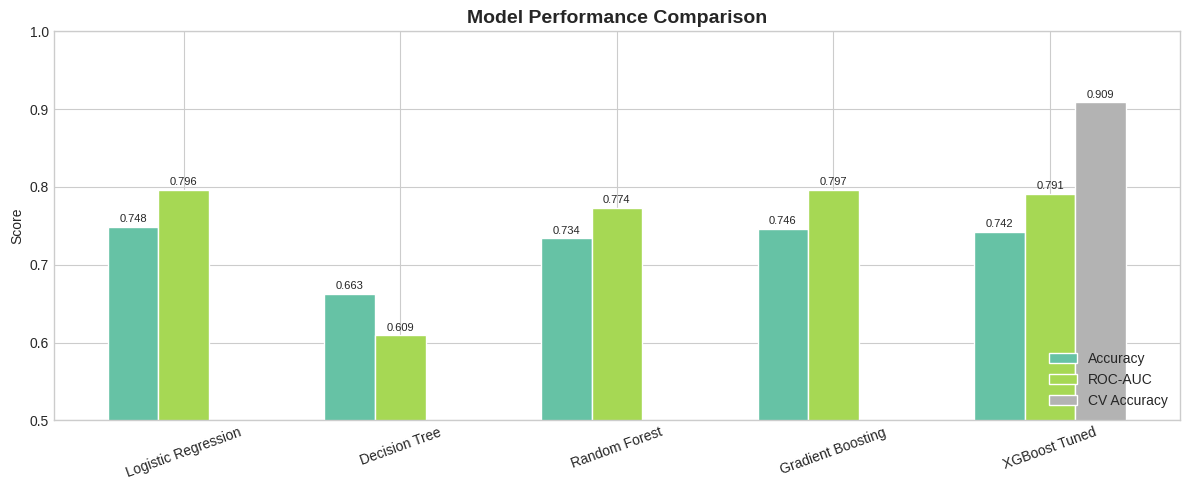

In [ ]:
from sklearn.metrics import roc_auc_score

# Calculate ROC-AUC for each model
y_proba_lr = model.predict_proba(X_test_sc)[:, 1]
y_proba_dt = dt_model.predict_proba(X_test_sc)[:, 1]
y_proba_rf = rf_model.predict_proba(X_test_sc)[:, 1]
y_proba_gb = gb_model.predict_proba(X_test_sc)[:, 1]

roc_auc_lr = roc_auc_score(y_test, y_proba_lr)
roc_auc_dt = roc_auc_score(y_test, y_proba_dt)
roc_auc_rf = roc_auc_score(y_test, y_proba_rf)
roc_auc_gb = roc_auc_score(y_test, y_proba_gb)
roc_auc_xgb_tuned = roc_auc_score(y_test, y_proba_xgb_tuned)

# Create a dictionary to store results, including the required y_proba and y_pred
results = {
    'Logistic Regression': {'Accuracy': accuracy, 'ROC-AUC': roc_auc_lr, 'CV Accuracy': 0, 'y_proba': y_proba_lr, 'y_pred': y_pred},
    'Decision Tree':       {'Accuracy': accuracy_dt, 'ROC-AUC': roc_auc_dt, 'CV Accuracy': 0, 'y_proba': y_proba_dt, 'y_pred': y_pred_dt},
    'Random Forest':       {'Accuracy': accuracy_rf, 'ROC-AUC': roc_auc_rf, 'CV Accuracy': 0, 'y_proba': y_proba_rf, 'y_pred': y_pred_rf},
    'Gradient Boosting':   {'Accuracy': accuracy_gb, 'ROC-AUC': roc_auc_gb, 'CV Accuracy': 0, 'y_proba': y_proba_gb, 'y_pred': y_pred_gb},
    'XGBoost Tuned':       {'Accuracy': accuracy_score(y_test, y_pred_xgb_tuned), 'ROC-AUC': roc_auc_xgb_tuned, 'CV Accuracy': xgb_grid.best_score_, 'y_proba': y_proba_xgb_tuned, 'y_pred': y_pred_xgb_tuned}
}

# Convert results to DataFrame
results_df = pd.DataFrame(results).T

# ── 8.1 Metric comparison bar chart ──────────────────────────────
ax = results_df[['Accuracy','ROC-AUC','CV Accuracy']].plot(
        kind='bar', figsize=(12, 5), colormap='Set2', edgecolor='white', width=0.7)
plt.title('Model Performance Comparison', fontsize=14, fontweight='bold')
plt.ylabel('Score')
plt.ylim(0.5, 1.0)
plt.xticks(rotation=20)
plt.legend(loc='lower right')
for container in ax.containers:
    ax.bar_label(container, fmt='%.3f', fontsize=8, padding=2)
plt.tight_layout()
plt.savefig('07_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

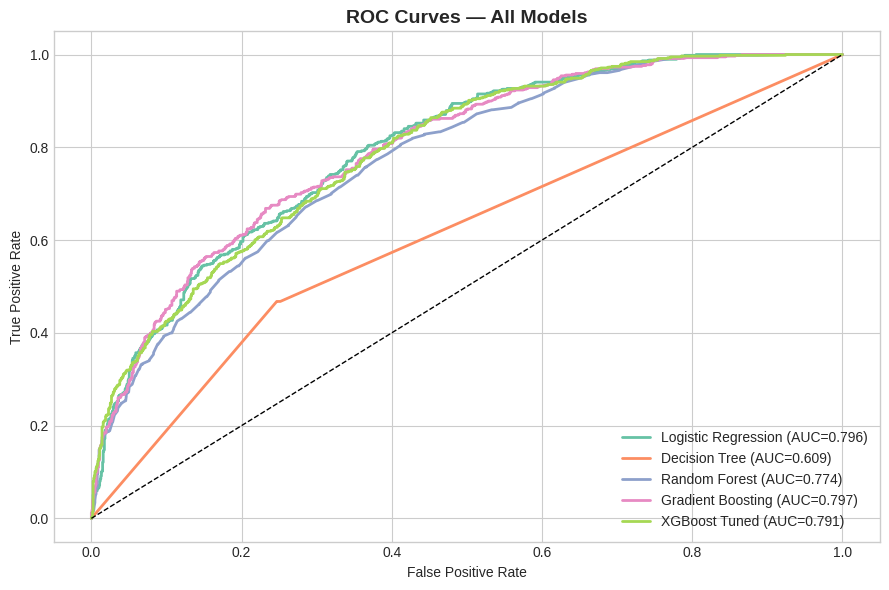

In [ ]:
# ── 8.2 ROC Curves ────────────────────────────────────────────────
plt.figure(figsize=(9, 6))
for name, res in results.items():
    fpr, tpr, _ = roc_curve(y_test, res['y_proba'])
    plt.plot(fpr, tpr, linewidth=2, label=f"{name} (AUC={res['ROC-AUC']:.3f})")
plt.plot([0,1],[0,1],'k--', linewidth=1)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves — All Models', fontsize=14, fontweight='bold')
plt.legend(loc='lower right')
plt.tight_layout()
plt.savefig('08_roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()

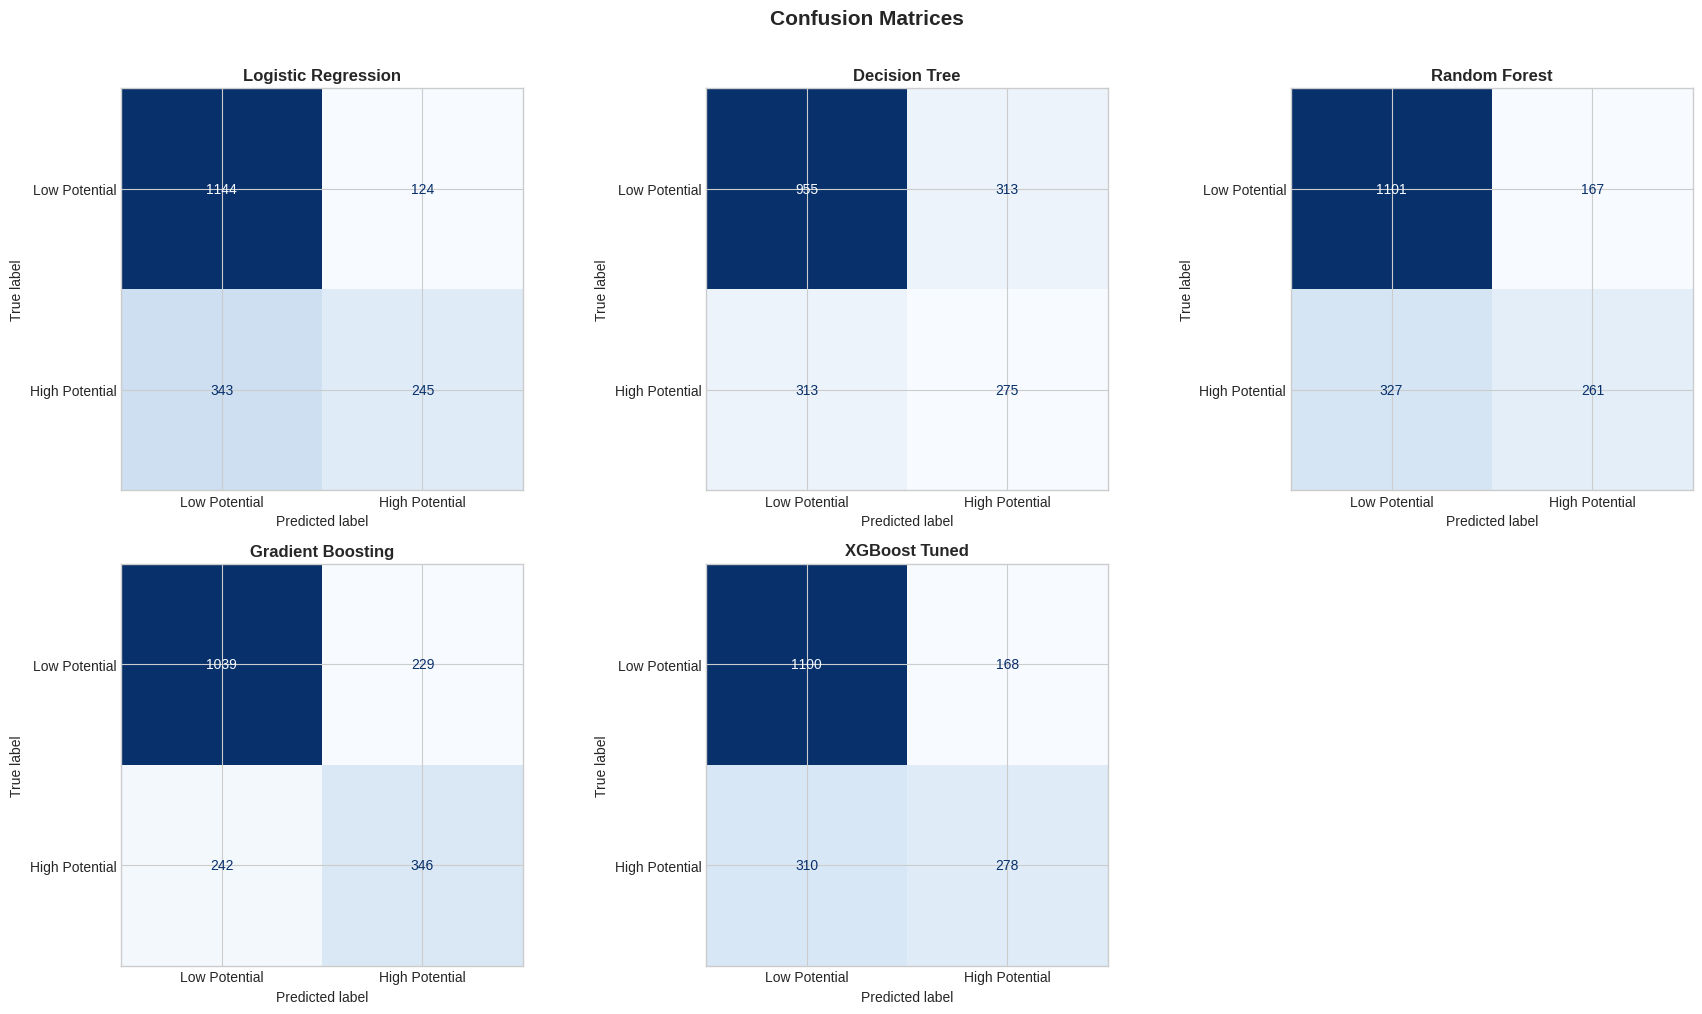

In [ ]:
# ── 8.3 Confusion matrices ────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(18, 10)) # Changed to 2x3 grid for 6 subplots
axes = axes.flatten()

for i, (name, res) in enumerate(results.items()):
    # Ensure we don't try to plot if there are more models than subplots
    if i < len(axes):
        cm = confusion_matrix(y_test, res['y_pred'])
        disp = ConfusionMatrixDisplay(cm, display_labels=['Low Potential','High Potential'])
        disp.plot(ax=axes[i], colorbar=False, cmap='Blues')
        axes[i].set_title(name, fontsize=12, fontweight='bold')
    else:
        # If there are more models than subplots (e.g., if you add more models later),
        # you might want to handle this case, e.g., print a warning or break.
        print(f"Warning: Not enough subplots for model {name}. Skipping confusion matrix.")

# Hide any unused subplots if the number of models is less than the total subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.suptitle('Confusion Matrices', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('09_confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

# **12. Best Model — Hyperparameter Tuning**

In [ ]:
# Select best model by ROC-AUC
best_name = results_df['ROC-AUC'].idxmax()
print(f" Best model: {best_name}  (AUC = {results_df.loc[best_name,'ROC-AUC']:.4f})")


 Best model: Gradient Boosting  (AUC = 0.7967)


In [ ]:
# ── GridSearchCV on Random Forest (adjust if best model differs) ──
param_grid = {
    'n_estimators':      [100, 200],
    'max_depth':         [None, 10, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf':  [1, 2],
}
rf_grid = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid, cv=5, scoring='roc_auc', n_jobs=-1, verbose=1
)
rf_grid.fit(X_train_sc, y_train_smote)

print(f"\n✅ Best params:  {rf_grid.best_params_}")
print(f"   Best CV AUC: {rf_grid.best_score_:.4f}")

best_model = rf_grid.best_estimator_
y_pred_best  = best_model.predict(X_test_sc)
y_proba_best = best_model.predict_proba(X_test_sc)[:, 1]

print(f"\nTest Accuracy: {accuracy_score(y_test, y_pred_best):.4f}")
print(f"Test ROC-AUC:  {roc_auc_score(y_test, y_proba_best):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_best, target_names=['Low Potential','High Potential']))

Fitting 5 folds for each of 24 candidates, totalling 120 fits

✅ Best params:  {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 200}
   Best CV AUC: 0.9068

Test Accuracy: 0.7435
Test ROC-AUC:  0.7910

Classification Report:
                precision    recall  f1-score   support

 Low Potential       0.77      0.88      0.82      1268
High Potential       0.64      0.44      0.52       588

      accuracy                           0.74      1856
     macro avg       0.71      0.66      0.67      1856
  weighted avg       0.73      0.74      0.73      1856



# **13. Feature Importance**

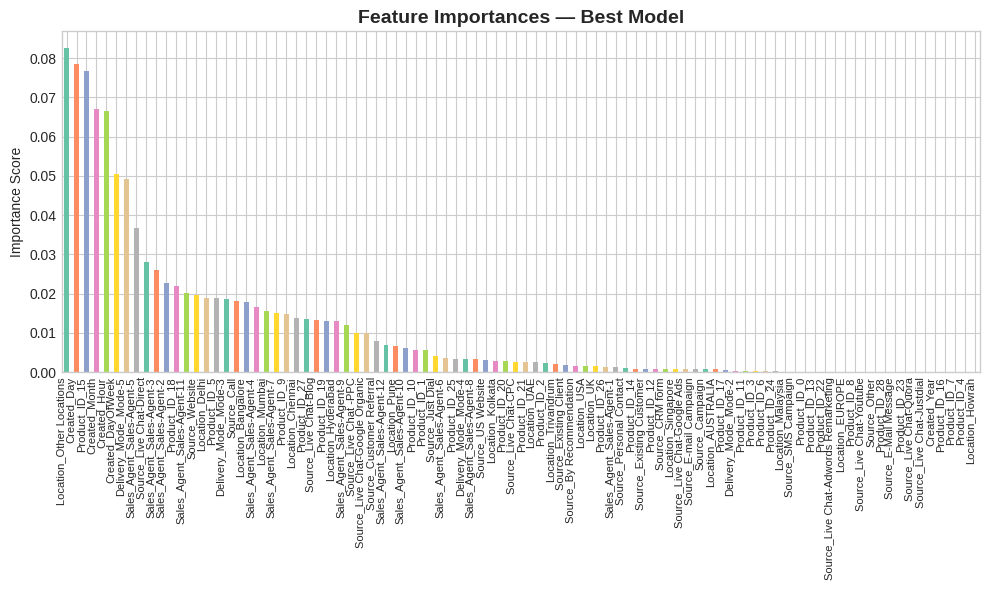


Top 5 most important features:
Location_Other Locations    0.082694
Created_Day                 0.078403
Product_ID_15               0.076635
Created_Month               0.067003
Created_Hour                0.066557
dtype: float64


In [ ]:
feature_cols = X.columns
importances = pd.Series(best_model.feature_importances_, index=feature_cols)                .sort_values(ascending=False)

plt.figure(figsize=(10, 6))
importances.plot(kind='bar', color=sns.color_palette("Set2", len(importances)))
plt.title('Feature Importances — Best Model', fontsize=14, fontweight='bold')
plt.ylabel('Importance Score')
plt.xticks(rotation=90, ha='right', fontsize=8) # Increased rotation and added fontsize
plt.tight_layout()
plt.savefig('10_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nTop 5 most important features:")
print(importances.head())

#   Business Insights & Recommendations

Based on the EDA and ML model analysis:

| # | Insight | Recommended Action |
|---|---------|-------------------|
| 1 | **Top lead sources** drive majority of High Potential leads | Increase marketing budget on best-performing channels |
| 2 | **Sales agent performance** varies significantly | Provide training to underperforming agents; pair with top agents |
| 3 | **Location clusters** show higher conversion rates | Focus field sales effort on high-conversion geographies |
| 4 | **Delivery mode** correlates with lead quality | Promote delivery modes preferred by High Potential leads |
| 5 | **Time patterns** in lead creation affect conversion | Prioritise follow-up on leads created on high-conversion days |
| 6 | **Missing Mobile** correlates with lower potential | Capture mobile during lead registration for better engagement |

> The ML model enables **proactive lead scoring**, allowing the sales team to prioritise High Potential leads immediately — shifting from reactive post-analysis to predictive sales effectiveness.


In [ ]:
# Global variables required for predict_lead function to align with training pipeline
# 1. Agent Lead Volume mapping (from original df)
# Using the `df` variable from the notebook state, which holds the pre-encoded data.
agent_volume = df['Sales_Agent'].value_counts().to_dict()

# 2. Categorical features that were one-hot encoded in training
categorical_cols_for_dummies = ['Product_ID', 'Source', 'Sales_Agent', 'Location', 'Delivery_Mode']

# 3. `feature_cols`, `scaler`, and `best_model` are expected to be in the global scope from earlier cells.

def predict_lead(new_lead_df):
    """
    Pass a DataFrame with the same raw columns as the original dataset.
    Returns the lead category and confidence score, applying preprocessing
    consistent with the training pipeline.
    """
    df_new = new_lead_df.copy()

    # --- Preprocessing steps mirroring the training pipeline ---

    # Handle '#VALUE!' in EMAIL (as done in cell 231b82d6)
    df_new['EMAIL'] = df_new['EMAIL'].replace('#VALUE!', np.nan)

    # Feature Engineering: Has_Mobile, Has_Email
    df_new['Has_Mobile'] = df_new['Mobile'].notna().astype(int)
    df_new['Has_Email'] = df_new['EMAIL'].notna().astype(int)

    # Date Feature Engineering (consistent with training: Created_Year, Month, Day, DayOfWeek, Hour)
    # (as done in cell 22ad03a8)
    df_new['Created'] = pd.to_datetime(df_new['Created'], errors='coerce', dayfirst=True)
    df_new['Created_Year'] = df_new['Created'].dt.year
    df_new['Created_Month'] = df_new['Created'].dt.month
    df_new['Created_Day'] = df_new['Created'].dt.day
    df_new['Created_DayOfWeek'] = df_new['Created'].dt.dayofweek
    df_new['Created_Hour'] = df_new['Created'].dt.hour

    # Drop original columns that were replaced or are not part of final features
    # (as done in cell 949f14a0 for Mobile, EMAIL, Status and Created in 22ad03a8)
    # 'Status' is not in new_lead_df initially, 'Mobile', 'EMAIL', 'Created' are
    df_new = df_new.drop(columns=['Mobile', 'EMAIL', 'Created'], errors='ignore')

    # One-hot encode categorical features (consistent with training, cell 3dec4e3f)
    df_new_encoded = pd.get_dummies(df_new, columns=categorical_cols_for_dummies, drop_first=True)

    # Convert boolean columns from get_dummies to integers (as done in cell f3bbbd2f)
    boolean_cols_in_new = df_new_encoded.select_dtypes(include=['bool']).columns
    for col in boolean_cols_in_new:
        df_new_encoded[col] = df_new_encoded[col].astype(int)

    # Align columns with the training data (feature_cols from global X.columns)
    # This is crucial to ensure the prediction function's input has the exact same columns
    # in the exact same order as the training data, filling missing with 0.
    # `feature_cols` was defined as `X.columns` in cell `74b7465a`.
    X_new_aligned = df_new_encoded.reindex(columns=feature_cols, fill_value=0)

    # Scale features using the fitted scaler (from cell vaDAe3Xs_xWl)
    X_new_sc = scaler.transform(X_new_aligned)

    # Predict and get probabilities using the best_model (from cell Yl42bZ3IPZKO)
    preds = best_model.predict(X_new_sc)
    probas = best_model.predict_proba(X_new_sc)[:, 1]

    # Assign predicted category and confidence
    df_new['Predicted_Category'] = ['High Potential' if p == 1 else 'Low Potential' for p in preds]
    df_new['Confidence_%'] = (probas * 100).round(1)

    return df_new[['Predicted_Category', 'Confidence_%']]

# Example usage (uncommented to run)
new_leads = pd.DataFrame([{
  'Created': '2024-06-15', 'Product_ID': 101.0, 'Source': 'Website',
     'Mobile': '9876543210', 'EMAIL': 'lead@example.com',
     'Sales_Agent': 'Agent_A', 'Location': 'Bangalore', 'Delivery_Mode': 'Online'
 }])
print(predict_lead(new_leads))

print("Prediction function ready — example above has been uncommented and aligned with training preprocessing")


  Predicted_Category  Confidence_%
0     High Potential          99.1
Prediction function ready — example above has been uncommented and aligned with training preprocessing


#  14. Save & Export Model

In [ ]:
import joblib

joblib.dump(best_model, 'lead_scoring_model.pkl')
joblib.dump(scaler,     'scaler.pkl')

print("✅ Model artifacts saved:")
print("   lead_scoring_model.pkl")
print("   scaler.pkl")

✅ Model artifacts saved:
   lead_scoring_model.pkl
   scaler.pkl


In [ ]:
# ── Final summary ─────────────────────────────────────────────────
print("=" * 55)
print("       PROJECT PRCL-0019 — FINAL SUMMARY")
print("=" * 55)
print(f"  Dataset rows       : {df.shape[0]:,}")
print(f"  Features used      : {len(feature_cols)}")
print(f"  Best model         : {best_name}")
print(f"  Test Accuracy      : {accuracy_score(y_test, y_pred_best)*100:.2f}%")
print(f"  Test ROC-AUC       : {roc_auc_score(y_test, y_proba_best):.4f}")
print("=" * 55)
print("   Notebook complete — Model ready for deployment")

       PROJECT PRCL-0019 — FINAL SUMMARY
  Dataset rows       : 7,422
  Features used      : 92
  Best model         : Gradient Boosting
  Test Accuracy      : 74.35%
  Test ROC-AUC       : 0.7910
   Notebook complete — Model ready for deployment
